# 📈 Crisis & Power Dynamics — Water Scarcity Simulation

Three visual angles on *how the crisis unfolds and how power shifts*, built from the numeric
fields we haven't used yet (`peak_temp_c`, `critical_failure`, `zones`, `weights`, `satisfaction`).

| § | Chart | Data | Question |
|---|-------|------|----------|
| 1 | 🌡️ **Crisis timeline** | `peak_temp_c`, `critical_failure`, `zones` | How does the heatwave drive sectors into distress? |
| 2 | ⚖️ **Power shift** | `weights` (`weight_after`, `delta`) | Whose influence with the Authority grows / collapses? |
| 3 | 😀 **Satisfaction heatmap** | `outcomes.satisfaction` | Who is kept happy, who is starved — and when? |

All metrics are **averaged across the 3 seeds and 3 conditions** (9 runs) for the overall
picture; §1 and §3 also show a per-condition breakdown.


In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors

plt.rcParams.update({"figure.dpi":110, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False,
                     "axes.grid":True, "grid.alpha":0.25})

def latest(prefix):
    files = sorted(glob.glob(f"{prefix}_*.csv") + glob.glob(f"../{prefix}_*.csv"))
    if not files: raise FileNotFoundError(f"{prefix}_*.csv not found in . or ..")
    return files[-1]

outcomes = pd.read_csv(latest("outcomes"))
weights  = pd.read_csv(latest("weights"))
zones    = pd.read_csv(latest("zones"))

LABELS = {"hospital":"Hospital","households":"Households","agriculture":"Agriculture",
          "industry":"Industry","energy_utility":"Energy","epa":"EPA",
          "water_authority":"Water Auth."}
# stable categorical colors per stakeholder
PALETTE = {"hospital":"#e63946","households":"#457b9d","agriculture":"#2a9d8f",
           "industry":"#8d6a9f","energy_utility":"#f4a261","epa":"#264653",
           "water_authority":"#6c757d"}
ZONE_COLORS = {"comfortable":"#2a9d8f","middle":"#e9c46a","critical":"#e63946"}

n_runs = zones.groupby(["condition","seed"]).ngroups
print("runs (condition×seed):", n_runs, "| days:", sorted(outcomes['day'].unique()))
print("sectors:", sorted(outcomes['stakeholder_id'].unique()))
outcomes.head(2)

runs (condition×seed): 9 | days: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
sectors: ['agriculture', 'energy_utility', 'epa', 'hospital', 'households', 'industry']


,day,stakeholder_id,name,requested,comfortable_threshold,critical_threshold,allocated,allocated_from_authority,allocated_from_trades,satisfaction,...,cooperated,objected,supply,total_allocated,peak_temp_c,ruling_text,cascade_increase,run_id,condition,seed
0,1,hospital,Hospital / Healthcare Services,150.0,132.0,97.5,150.0,150.0,0.0,1.000,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0
1,1,households,Households,400.0,312.0,220.0,365.0,365.0,0.0,0.912,...,False,False,1000.0,1000.0,34.0,"Given today’s severe shortage and high heat, w...",0.0,no_cascade_seed0,no_cascade,0


## 1. 🌡️ Crisis timeline
Three synced panels over the 6 simulation days:
1. **Peak temperature** — the external heat driver.
2. **Sectors in critical failure** — average number of sectors that fell below their critical line.
3. **Zone composition** — how the 6 sectors split across *comfortable / middle / critical*.

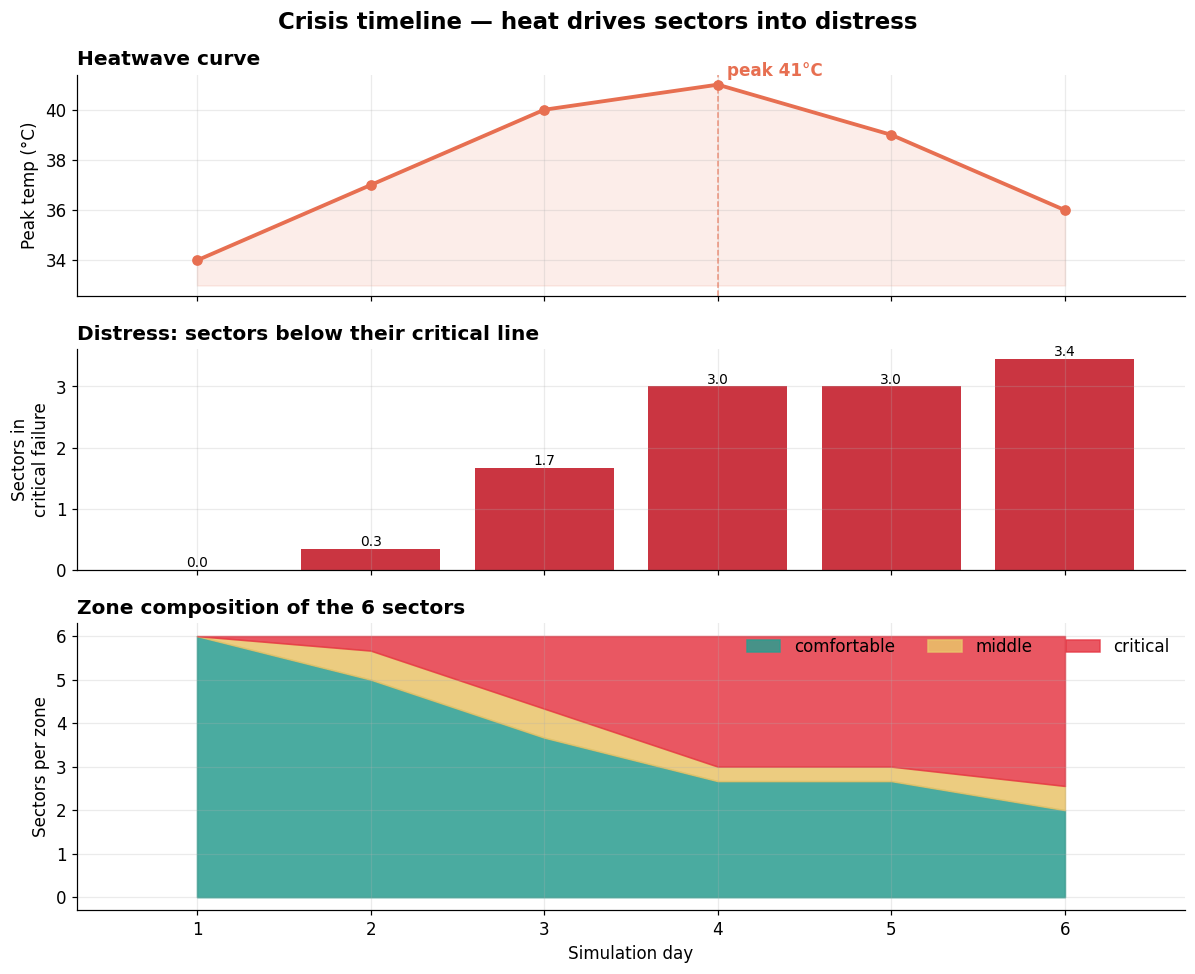

In [2]:
days = sorted(outcomes["day"].unique())

temp   = outcomes.groupby("day")["peak_temp_c"].mean()
# mean number of sectors in critical failure per run per day
crit   = outcomes.groupby("day")["critical_failure"].mean() * outcomes["stakeholder_id"].nunique()
# mean number of sectors in each zone per day
zcount = (zones.groupby(["day","zone"]).size().unstack(fill_value=0) / n_runs)
zcount = zcount.reindex(columns=["comfortable","middle","critical"], fill_value=0)

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                       gridspec_kw={"height_ratios":[1,1,1.3]})

# panel 1: temperature
ax[0].plot(temp.index, temp.values, "-o", color="#e76f51", lw=2.5)
ax[0].fill_between(temp.index, temp.values, temp.min()-1, color="#e76f51", alpha=0.12)
ax[0].axvline(temp.idxmax(), color="#e76f51", ls="--", lw=1, alpha=0.7)
ax[0].set_ylabel("Peak temp (°C)")
ax[0].set_title("Heatwave curve", loc="left", weight="bold")
ax[0].annotate(f"peak {temp.max():.0f}°C", (temp.idxmax(), temp.max()),
               textcoords="offset points", xytext=(6,6), color="#e76f51", weight="bold")

# panel 2: critical failures
ax[1].bar(crit.index, crit.values, color="#c1121f", alpha=0.85)
ax[1].set_ylabel("Sectors in\ncritical failure")
ax[1].set_title("Distress: sectors below their critical line", loc="left", weight="bold")
for x,v in crit.items():
    ax[1].text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

# panel 3: zone composition (stacked area)
bottom = np.zeros(len(zcount))
for zname in ["comfortable","middle","critical"]:
    ax[2].fill_between(zcount.index, bottom, bottom+zcount[zname].values,
                       color=ZONE_COLORS[zname], alpha=0.85, label=zname)
    bottom += zcount[zname].values
ax[2].set_ylabel("Sectors per zone"); ax[2].set_xlabel("Simulation day")
ax[2].set_title("Zone composition of the 6 sectors", loc="left", weight="bold")
ax[2].legend(loc="upper right", ncol=3, frameon=False)
ax[2].set_xticks(days)

fig.suptitle("Crisis timeline — heat drives sectors into distress", fontsize=15, weight="bold")
plt.tight_layout(); plt.show()

### Crisis timeline per condition
Same *sectors-in-critical-failure* metric, split by scenario — does cascading deepen the crisis?

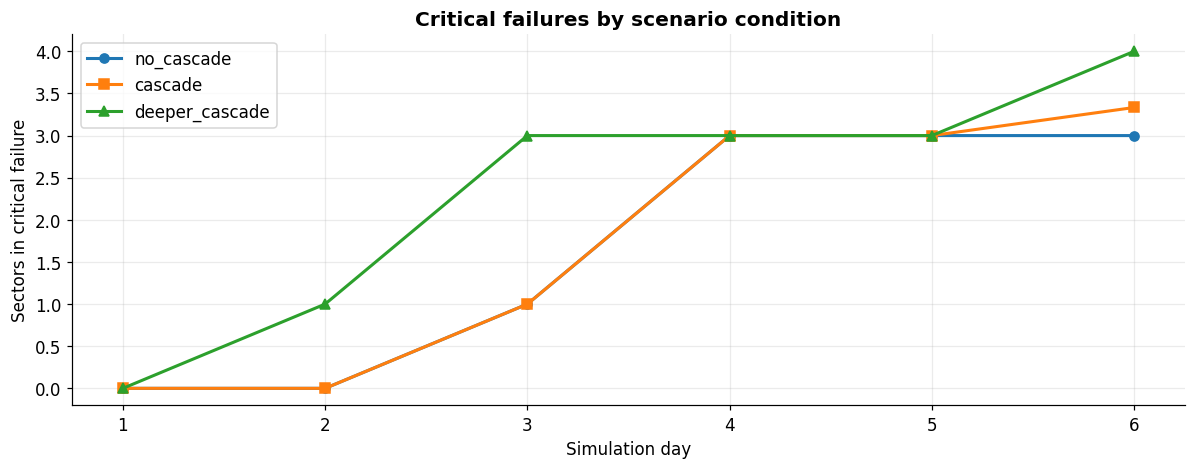

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.4))
for c, style in zip(["no_cascade","cascade","deeper_cascade"], ["-o","-s","-^"]):
    sub = outcomes[outcomes["condition"]==c]
    series = sub.groupby("day")["critical_failure"].mean() * sub["stakeholder_id"].nunique()
    ax.plot(series.index, series.values, style, lw=2, label=c)
ax.set_xlabel("Simulation day"); ax.set_ylabel("Sectors in critical failure")
ax.set_title("Critical failures by scenario condition", weight="bold")
ax.set_xticks(days); ax.legend(); plt.tight_layout(); plt.show()

## 2. ⚖️ Power shift
The Authority assigns each sector a **priority weight**. Tracking `weight_after` over time shows
whose influence **grew** and whose **collapsed**.

The right panel breaks each sector's final weight into its **initial value (day 1 — what the
Water Authority handed out at the start)** plus the **net gain** by day 6, and reports the total
priority "pie" the Authority distributed (Σ).

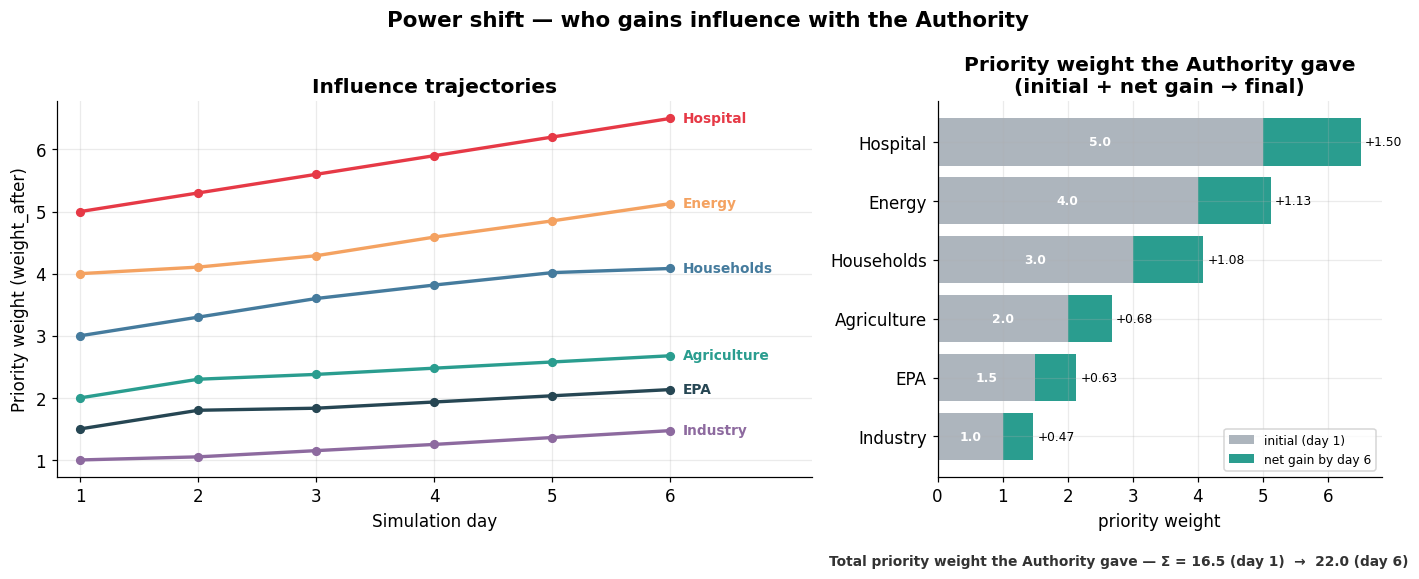

In [4]:
wtraj = (weights.groupby(["stakeholder_id","day"])["weight_after"].mean()
         .unstack("day"))
wtraj = wtraj.reindex(columns=days)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2),
                         gridspec_kw={"width_ratios":[1.7,1]})

# left: trajectories (slope-chart style)
for sid, row in wtraj.iterrows():
    axes[0].plot(row.index, row.values, "-o", color=PALETTE.get(sid,"#888"), lw=2.2,
                 markersize=5)
    axes[0].annotate(LABELS.get(sid,sid), (row.index[-1], row.values[-1]),
                     textcoords="offset points", xytext=(8,0), va="center",
                     color=PALETTE.get(sid,"#888"), weight="bold", fontsize=9)
axes[0].set_xlabel("Simulation day"); axes[0].set_ylabel("Priority weight (weight_after)")
axes[0].set_title("Influence trajectories", weight="bold")
axes[0].set_xticks(days); axes[0].set_xlim(days[0]-0.2, days[-1]+1.2)

# right: initial weight (what the Authority gave on day 1) + net gain, stacked
init  = wtraj[days[0]]
net   = wtraj[days[-1]] - wtraj[days[0]]
final = wtraj[days[-1]]
order = final.sort_values().index            # largest final ends up on top
y = np.arange(len(order))
ylab = [LABELS.get(i,i) for i in order]

axes[1].barh(y, init.reindex(order).values, color="#adb5bd", label="initial (day 1)")
axes[1].barh(y, net.reindex(order).values, left=init.reindex(order).values,
             color="#2a9d8f", label="net gain by day 6")
for i, sid in enumerate(order):
    axes[1].text(init[sid]/2, i, f"{init[sid]:.1f}", va="center", ha="center",
                 color="white", fontsize=8, weight="bold")
    axes[1].text(final[sid]+0.06, i, f"+{net[sid]:.2f}", va="center", ha="left", fontsize=8)
axes[1].set_yticks(y); axes[1].set_yticklabels(ylab)
axes[1].set_title("Priority weight the Authority gave\n(initial + net gain → final)",
                  weight="bold")
axes[1].set_xlabel("priority weight")
axes[1].legend(loc="lower right", fontsize=8, frameon=True)

fig.suptitle("Power shift — who gains influence with the Authority", fontsize=14, weight="bold")
# total priority "pie" the Authority handed out, day 1 vs day 6
fig.text(0.99, 0.005,
         f"Total priority weight the Authority gave — Σ = {init.sum():.1f} (day 1)  →  {final.sum():.1f} (day 6)",
         ha="right", va="bottom", fontsize=9, color="#333", weight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 3. 😀 Satisfaction heatmap
`satisfaction` runs 0 (starved) → 1 (fully met). Rows = sectors, columns = days.
Green = satisfied, red = unmet.

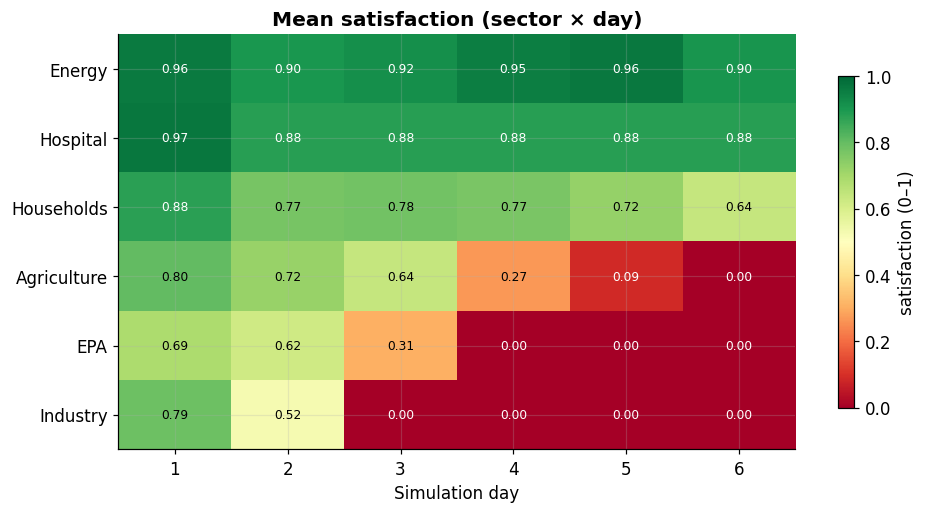

In [5]:
sat = (outcomes.groupby(["stakeholder_id","day"])["satisfaction"].mean()
       .unstack("day").reindex(columns=days))
# order rows by overall satisfaction (worst at bottom)
sat = sat.loc[sat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(sat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(days))); ax.set_xticklabels(days)
ax.set_yticks(range(len(sat.index))); ax.set_yticklabels([LABELS.get(i,i) for i in sat.index])
ax.set_xlabel("Simulation day"); ax.set_title("Mean satisfaction (sector × day)", weight="bold")
for i in range(sat.shape[0]):
    for j in range(sat.shape[1]):
        v = sat.values[i,j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="black" if 0.25<v<0.85 else "white", fontsize=8)
fig.colorbar(im, ax=ax, label="satisfaction (0–1)", shrink=0.8)
plt.tight_layout(); plt.show()

### Satisfaction by condition
Does the cascade scenario starve more sectors?

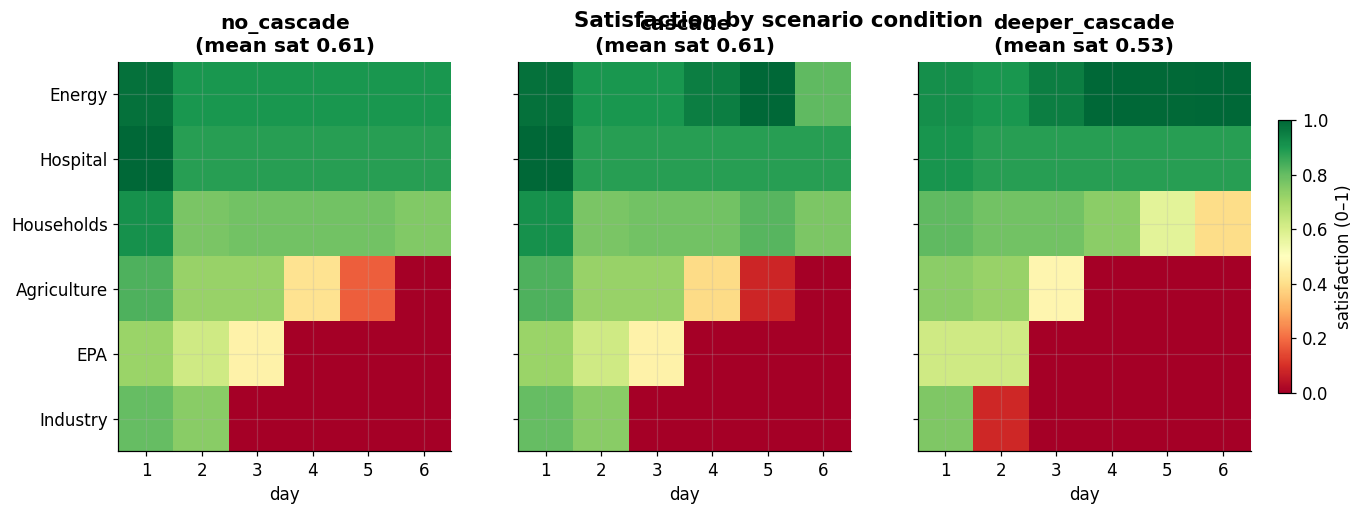

In [6]:
conds = ["no_cascade","cascade","deeper_cascade"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
row_order = sat.index  # keep same row order as the averaged heatmap
for ax, c in zip(axes, conds):
    sub = outcomes[outcomes["condition"]==c]
    m = (sub.groupby(["stakeholder_id","day"])["satisfaction"].mean()
         .unstack("day").reindex(index=row_order, columns=days))
    im = ax.imshow(m.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(days))); ax.set_xticklabels(days)
    ax.set_title(f"{c}\n(mean sat {np.nanmean(m.values):.2f})", weight="bold")
    ax.set_xlabel("day")
axes[0].set_yticks(range(len(row_order)))
axes[0].set_yticklabels([LABELS.get(i,i) for i in row_order])
fig.colorbar(im, ax=axes, label="satisfaction (0–1)", shrink=0.7, pad=0.02)
fig.suptitle("Satisfaction by scenario condition", fontsize=14, weight="bold")
plt.show()

## Takeaways

- **Crisis timeline** (§1): temperature peaks mid-run (day 4, 41°C); the *critical-failure* and
  *zone* panels show how many sectors are pushed below their safety line as the heat bites.
- **Power shift** (§2): the influence trajectories reveal who the Authority progressively
  favors — and the net-change bars name the winners (green) and losers (red) of the crisis.
- **Satisfaction heatmap** (§3): a direct map of who gets served vs starved, by day; the
  per-condition panels show whether cascading scenarios spread the pain wider.

> Cross-link idea: overlay §3 satisfaction against the VADER sentiment heatmap from the NLP
> notebook — do sectors *sound* as unhappy as their allocation says they should be?
